# Evaluierung & Analyse des Loss-Aggregations-Experiments (Sum vs. Mean DPO)

Dieses Notebook analysiert und vergleicht den Einfluss der **Sequenz-Wahrscheinlichkeits-Aggregation** im Direct Preference Optimization (DPO) Training auf das Encoder-Decoder-Modell (`facebook/mbart-large-50`):

1. **Klassische Summierung (`sum`):** $\log \pi(y \mid x) = \sum_{t=1}^T \log \pi(y_t \mid x, y_{<t})$
   * *Hypothese:* Akkumuliert negative Log-Wahrscheinlichkeiten proportional zur Textlänge. Das Modell lernt eine Kürzungsstrategie (Degeneration auf kurze Satzfragmente).
2. **Längen-normalisierter Mittelwert (`mean`):** $\overline{\log \pi(y \mid x)} = \frac{1}{T} \sum_{t=1}^T \log \pi(y_t \mid x, y_{<t})$
   * *Hypothese:* Eliminiert den Längen-Bias und bewertet die durchschnittliche Modellzuversicht pro generiertem Token, wodurch vollständige Leichte-Sprache-Sätze erhalten bleiben.

### Untersuchte Modellvarianten:
- **SFT Baseline:** Supervised Fine-Tuning Referenz (`results/models/sft`)
- **DPO Sum (Classic):** DPO-Training mit summierten Log-Likelihoods (`results/models/loss_aggregation_exp/dpo_sum`)
- **DPO Mean (Length-Normalized):** DPO-Training mit gemittelten Log-Likelihoods (`results/models/loss_aggregation_exp/dpo_mean`)

In [1]:
import os
import sys
import json
import glob
from typing import List, Dict, Any, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import torch

def find_repo_root():
    p = os.path.abspath(os.getcwd())
    while p != os.path.dirname(p):
        if os.path.exists(os.path.join(p, 'data')) and os.path.exists(os.path.join(p, 'results')):
            return p
        p = os.path.dirname(p)
    return os.path.abspath(os.path.expanduser('~/Documents/Master Thesis'))

REPO_ROOT = find_repo_root()
os.chdir(REPO_ROOT)
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu'))
print('Arbeitsverzeichnis:', os.getcwd())
print(f'Nutze Device: {DEVICE}')

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.dpi'] = 150


Arbeitsverzeichnis: /Users/fietescheel/Documents/Master Thesis
Nutze Device: mps


## 1. Evaluationsdaten laden

Einlesen der Aggregations- und Detail-Evaluationsdaten.

In [2]:
SUMMARY_CSV = os.path.join(REPO_ROOT, 'results/evaluation/loss_aggregation_comparison_summary.csv')
DETAILS_CSV = os.path.join(REPO_ROOT, 'results/evaluation/loss_aggregation_comparison_details.csv')
os.makedirs(os.path.join(REPO_ROOT, 'results/plots'), exist_ok=True)

if os.path.exists(SUMMARY_CSV):
    df_summary = pd.read_csv(SUMMARY_CSV)
    print(f'Zusammenfassung erfolgreich geladen: {len(df_summary)} Modelle aus {SUMMARY_CSV}')
    display(df_summary)
else:
    print(f'Warnung: {SUMMARY_CSV} nicht gefunden.')
    df_summary = pd.DataFrame()

if os.path.exists(DETAILS_CSV):
    df_details = pd.read_csv(DETAILS_CSV)
    print(f'Detail-Ergebnisse erfolgreich geladen: {len(df_details)} Zeilen aus {DETAILS_CSV}')
else:
    print(f'Warnung: {DETAILS_CSV} nicht gefunden.')
    df_details = pd.DataFrame()

Zusammenfassung erfolgreich geladen: 3 Modelle aus /Users/fietescheel/Documents/Master Thesis/results/evaluation/loss_aggregation_comparison_summary.csv


,Modell,model_key,model_path,r_style_mean,r_sem_as_mean,sim_ref_mean,composite_reward_mean,bleu_mean,rouge_l_mean,avg_gen_tokens,compression_ratio_mean,truncation_rate_pct
0,SFT Baseline,SFT Baseline,results/models/sft,0.729370,0.854447,0.839101,0.791909,0.006753,0.124114,136.675676,0.337876,45.945946
1,DPO Sum (Classic),DPO Sum (Classic),results/models/loss_aggregation_exp/dpo_sum,0.976109,0.846779,0.846578,0.911444,0.008693,0.142333,176.162162,0.407008,75.675676
2,DPO Mean (Length-Normalized),DPO Mean (Length-Normalized),results/models/loss_aggregation_exp/dpo_mean,0.971069,0.642810,0.669160,0.806940,0.000639,0.123784,174.378378,0.407910,59.459459


Detail-Ergebnisse erfolgreich geladen: 111 Zeilen aus /Users/fietescheel/Documents/Master Thesis/results/evaluation/loss_aggregation_comparison_details.csv


## 2. Quantitative Vergleichstabelle

In [3]:
if 'df_summary' in locals() and len(df_summary) > 0:
    styled_df = df_summary.copy()
    for col in styled_df.columns:
        if col != "Modell" and col != "model_name":
            styled_df[col] = styled_df[col].apply(lambda x: f"{x:.4f}" if isinstance(x, (float, int, np.floating)) else x)
    display(styled_df)
    
    print("\n=== Markdown-Tabelle  ===\n")
    try:
        print(styled_df.to_markdown(index=False))
    except Exception:
        cols = [str(c) for c in styled_df.columns]
        header = "| " + " | ".join(cols) + " |"
        sep = "| " + " | ".join(["---"] * len(cols)) + " |"
        rows = ["| " + " | ".join([str(val) for val in row]) + " |" for row in styled_df.values]
        print("\n".join([header, sep] + rows))
else:
    print("Keine Zusammenfassungstabelle verfuegbar.")

,Modell,model_key,model_path,r_style_mean,r_sem_as_mean,sim_ref_mean,composite_reward_mean,bleu_mean,rouge_l_mean,avg_gen_tokens,compression_ratio_mean,truncation_rate_pct
0,SFT Baseline,SFT Baseline,results/models/sft,0.7294,0.8544,0.8391,0.7919,0.0068,0.1241,136.6757,0.3379,45.9459
1,DPO Sum (Classic),DPO Sum (Classic),results/models/loss_aggregation_exp/dpo_sum,0.9761,0.8468,0.8466,0.9114,0.0087,0.1423,176.1622,0.4070,75.6757
2,DPO Mean (Length-Normalized),DPO Mean (Length-Normalized),results/models/loss_aggregation_exp/dpo_mean,0.9711,0.6428,0.6692,0.8069,0.0006,0.1238,174.3784,0.4079,59.4595



=== Markdown-Tabelle  ===

| Modell                       | model_key                    | model_path                                   |   r_style_mean |   r_sem_as_mean |   sim_ref_mean |   composite_reward_mean |   bleu_mean |   rouge_l_mean |   avg_gen_tokens |   compression_ratio_mean |   truncation_rate_pct |
|:-----------------------------|:-----------------------------|:---------------------------------------------|---------------:|----------------:|---------------:|------------------------:|------------:|---------------:|-----------------:|-------------------------:|----------------------:|
| SFT Baseline                 | SFT Baseline                 | results/models/sft                           |         0.7294 |          0.8544 |         0.8391 |                  0.7919 |      0.0068 |         0.1241 |          136.676 |                   0.3379 |               45.9459 |
| DPO Sum (Classic)            | DPO Sum (Classic)            | results/models/loss_aggregation_exp/dp

## 3. Visualisierungen: Textlänge, Truncation & Trade-Off

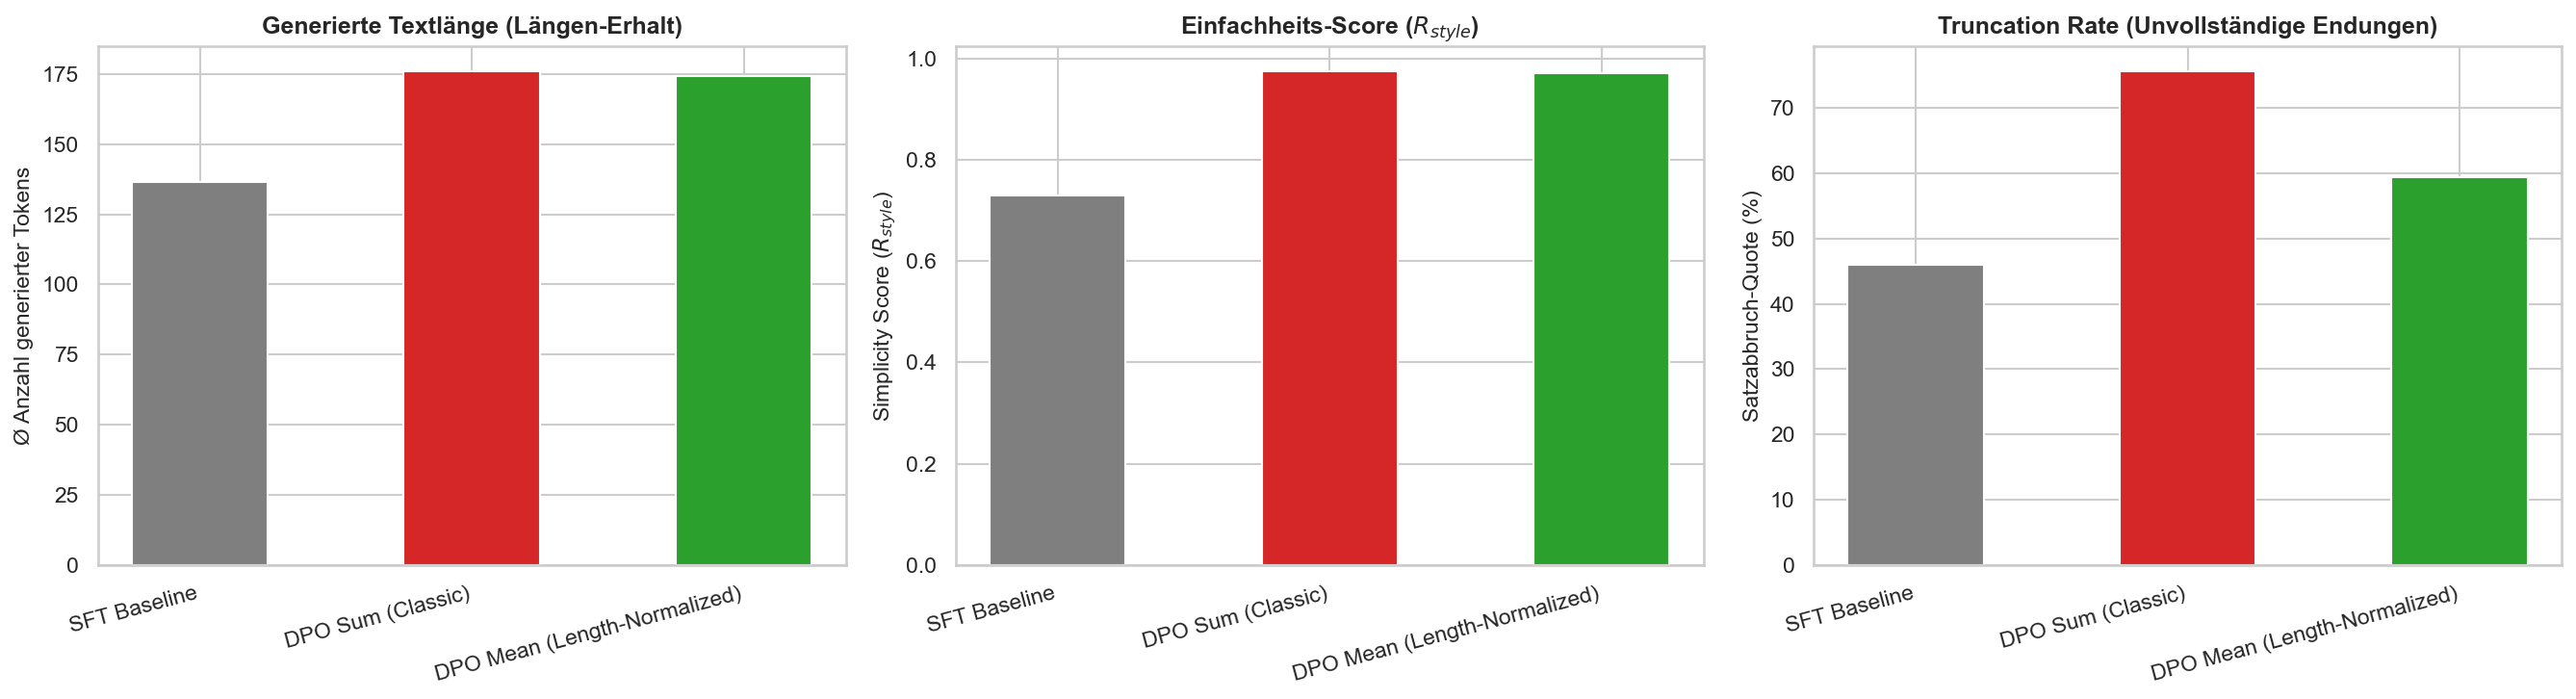

In [4]:
if 'df_summary' in locals() and len(df_summary) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    name_col = [c for c in df_summary.columns if "Modell" in c or "model" in c][0]
    models = df_summary[name_col]
    x = np.arange(len(models))
    
    # Generierte Token-Länge
    tok_col = [c for c in df_summary.columns if "Tokens" in c or "avg_gen_tokens" in c][0]
    axes[0].bar(x, df_summary[tok_col].astype(float), color=["#7f7f7f", "#d62728", "#2ca02c"], width=0.5)
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(models, rotation=15, ha="right")
    axes[0].set_ylabel("Ø Anzahl generierter Tokens", fontsize=11)
    axes[0].set_title("Generierte Textlänge (Längen-Erhalt)", fontsize=12, fontweight="bold")
    
    # Simplicity Score
    simp_col = [c for c in df_summary.columns if "Simplicity" in c or "r_style" in c][0]
    axes[1].bar(x, df_summary[simp_col].astype(float), color=["#7f7f7f", "#d62728", "#2ca02c"], width=0.5)
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(models, rotation=15, ha="right")
    axes[1].set_ylabel("Simplicity Score ($R_{style}$)", fontsize=11)
    axes[1].set_title("Einfachheits-Score ($R_{style}$)", fontsize=12, fontweight="bold")
    
    # Truncation Rate (%)
    trunc_col = [c for c in df_summary.columns if "Truncation" in c or "truncation" in c][0]
    axes[2].bar(x, df_summary[trunc_col].astype(float), color=["#7f7f7f", "#d62728", "#2ca02c"], width=0.5)
    axes[2].set_xticks(x)
    axes[2].set_xticklabels(models, rotation=15, ha="right")
    axes[2].set_ylabel("Satzabbruch-Quote (%)", fontsize=11)
    axes[2].set_title("Truncation Rate (Unvollständige Endungen)", fontsize=12, fontweight="bold")
    
    plt.tight_layout()
    plt.savefig("results/plots/loss_aggregation_length_comparison.png", dpi=300)
    plt.show()
else:
    print("Keine Zusammenfassungsdaten fuer Plots vorhanden.")

## 4. Qualitativer Side-by-Side Modellvergleich (Beispielsätze)

In [5]:
if 'df_details' in locals() and len(df_details) > 0:
    sample_queries = df_details["as_text"].unique()[:4]
    
    for idx, as_s in enumerate(sample_queries, 1):
        sub_df = df_details[df_details["as_text"] == as_s]
        ls_ref = sub_df["ls_ref_text"].iloc[0]
        
        print(f"\n{'#'*90}")
        print(f"BEISPIEL {idx}:")
        print(f"[AS Quelle] : {as_s}")
        print(f"[LS Referenz]: {ls_ref}")
        print(f"{'-'*90}")
        
        for _, r in sub_df.iterrows():
            print(f"[{r['model_name']:30s}] (Simp: {r['r_style']:.3f} | Sem-AS: {r['r_sem_as']:.3f} | Tokens: {r['gen_tokens']}):")
            print(f"  {r['generated_text']}\n")
else:
    print("Keine Detail-Uebersetzungen verfuegbar.")


##########################################################################################
BEISPIEL 1:
[AS Quelle] : Kiel, 15.10.2020. Arbeit zweiter oder dritter Klasse?? - Positionspapier Die Rede ist in diesemFall von der Entlohnung für Menschen, die in einer Werkstatt (WfbM) arbeiten. Wichtiges Detail: Es sind die Werkstätten selbst, die diese Veränderung dringend fordern. Der Lohn der Mitarbeiter*innen mit Werkstattvertrag ist bei einem 6 – 8 Stunden Arbeitstag weit davon entfernt, auf dieser Basis ein selbstfinanziertes Leben führen zu können. Das bedeutet, dass die Menschen grundsätzlich Grundsicherung beantragen müssen, um ihren Lebensunterhalt zu bestreiten – es sei denn, sie erhalten bereits eine Erwerbsminderungsrente und können in der Werkstatt noch so viel dazu verdienen, dass es gerade zum Leben reicht. Die Pandemie-bedingten Betretungsverbote für die WfbMs und die damit aller Orten eingebrochenen Erträge machen die Auszahlung dieser Löhne nun aber auch immer schwieriger